# 1 Find_S_Algorithm 

In [16]:
dataset=[
    ['red','small','round','sweet',1],
    ['green','large','round','sour',0],
    ['red','large','round','sweet',1],
    ['yellow','small','oblong','sweet',0],
    ['red','small','round','sweet',1],
    ['red','large','oblong','sour',1],
    ['yellow','small','round','sweet',0],
    ['green','medium','oblong','sweet',0]
]

hypothesis=['None','None','None','None']
for example in dataset:
    if example[-1]==1:
        for i in range(len(hypothesis)):
              if hypothesis[i]=='None':
                   hypothesis[i]=example[i]
              elif hypothesis[i]!=example[i]:
                  hypothesis[i]='?'
                    
print("The most specific hypothesis is ",hypothesis)
        

The most specific hypothesis is  ['red', '?', '?', '?']


# 2 ID3

Accuracy: 0.6
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.67      0.67      0.67         3

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5



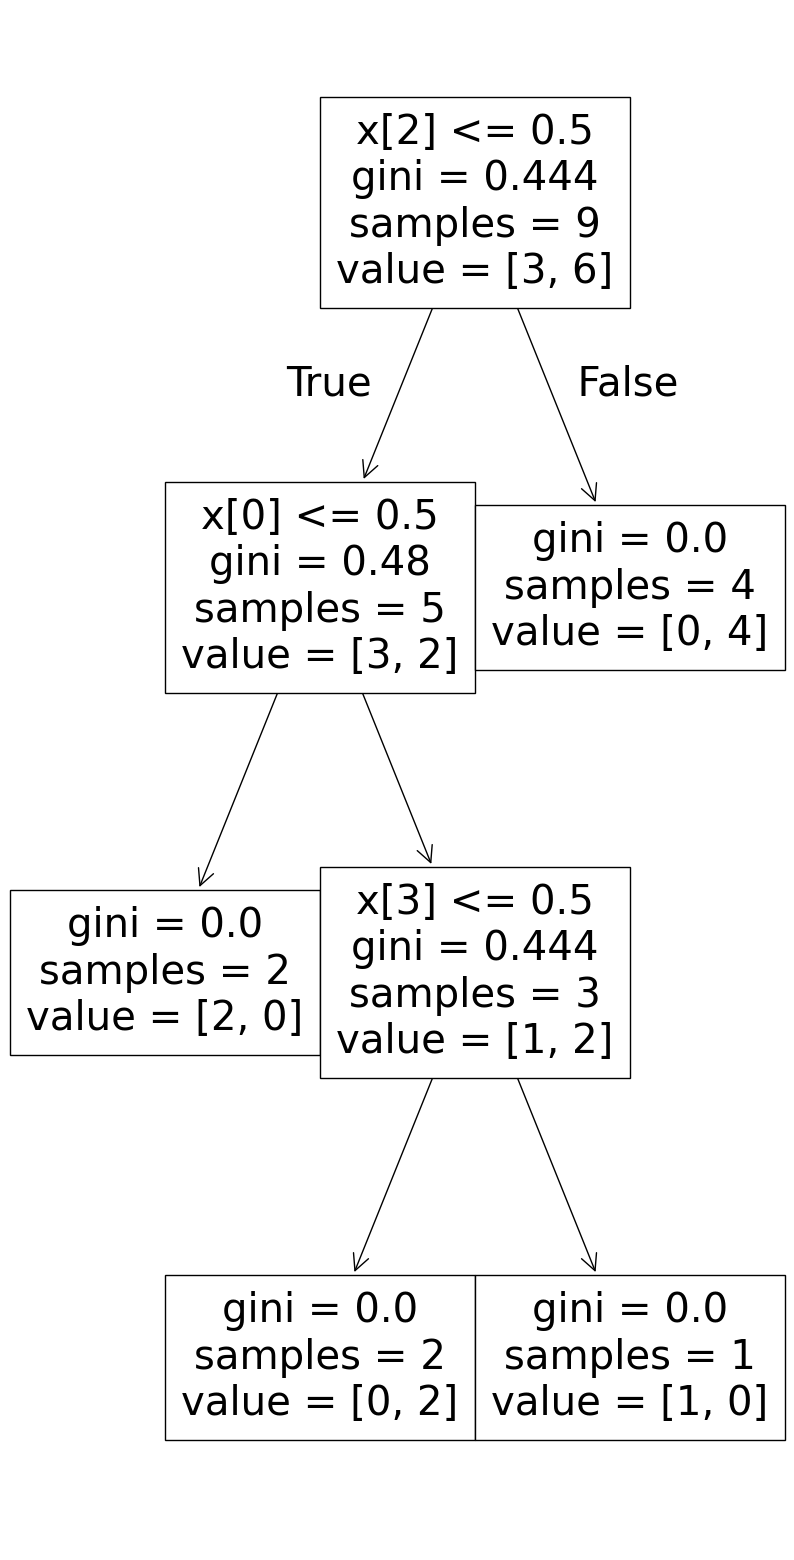

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Data (Already Encoded Numerically)
data= {
    'Outlook': [0, 0, 1, 2, 2, 2, 1, 0, 0, 2, 0, 1, 1, 2],  # Sunny=0, Overcast=1, Rain=2
    'Temperature': [0, 0, 0, 1, 2, 2, 2, 1, 2, 1, 1, 1, 0, 1],  # Hot=0, Mild=1, Cool=2
    'Humidity': [0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],  # High=0, Normal=1
    'Windy': [0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1],  # False=0, True=1
    'Play': [0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0]  # No=0, Yes=1
}

df = pd.DataFrame(data)

# Preprocessing
X, y = df.drop('Play', axis=1), df['Play']

# Model Training & Evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = DecisionTreeClassifier(criterion='gini', random_state=42).fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Plot Tree
plt.figure(figsize=(10,20))
plot_tree(model)
plt.show()


# 3 Random Forest 

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train Random Forest Classifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Random Forest Accuracy: {accuracy*100:.2f}")
print("Classification Report:\n", report)


Random Forest Accuracy: 96.49
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95        63
           1       0.96      0.98      0.97       108

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



# 4 Linear Regression


MSE: 0.038665912378257894
R²: 0.9442318571467434


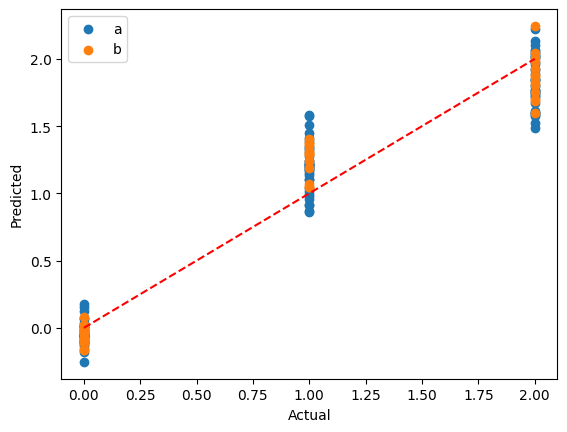

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load data
iris = load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model = LinearRegression().fit(X_train, y_train)

# Predict
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Metrics
print("MSE:", mean_squared_error(y_test, y_pred_test))
print("R²:", r2_score(y_test, y_pred_test))

# Simple plot
plt.scatter(y_train, y_pred_train,label='a')
plt.scatter(y_test, y_pred_test,label='b')
plt.legend()
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()



# 5 Logistic Regression

In [2]:
# Import necessary libraries
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report

# Load the digits dataset
digits = load_digits()

# Features (X) and Target (y)
X = digits.data # Each row is a flattened image (8x8 pixels)
y = digits.target # Target digit (0-9)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000).fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 96.85%

Confusion Matrix:
[[53  0  0  0  0  0  0  0  0  0]
 [ 0 47  1  0  0  0  0  0  2  0]
 [ 0  0 47  0  0  0  0  0  0  0]
 [ 0  0  1 52  0  1  0  0  0  0]
 [ 0  1  0  0 58  0  1  0  0  0]
 [ 0  1  0  0  0 63  1  0  0  1]
 [ 0  0  0  0  0  1 52  0  0  0]
 [ 0  0  0  0  0  1  0 53  0  1]
 [ 0  0  0  0  0  1  0  0 42  0]
 [ 0  0  0  1  0  0  0  0  2 56]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.96      0.94      0.95        50
           2       0.96      1.00      0.98        47
           3       0.98      0.96      0.97        54
           4       1.00      0.97      0.98        60
           5       0.94      0.95      0.95        66
           6       0.96      0.98      0.97        53
           7       1.00      0.96      0.98        55
           8       0.91      0.98      0.94        43
           9       0.97      0.95      0.96        59

    accuracy 

# 6 K-Means Clustering 

In [7]:
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import mode
import numpy as np

# Load data
X, y = load_digits().data,load_digits().target

# Train K-Means
kmeans = KMeans(n_clusters=10, random_state=42).fit(X)

# Map clusters to actual labels
labels = [mode(y[kmeans.labels_ == i])[0] for i in kmeans.labels_]

# Evaluate
print(f"K-Means Accuracy: {accuracy_score(y, labels) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y, labels))


K-Means Accuracy: 86.14%

Confusion Matrix:
 [[176   0   0   0   2   0   0   0   0   0]
 [  0 130  23   1   0   1   2   0   3  22]
 [  1   6 146  12   0   0   0   2   9   1]
 [  0   0   1 159   0   2   0   7   6   8]
 [  0  13   0   0 159   0   0   5   4   0]
 [  0   0   0   0   2 137   2   0   0  41]
 [  1   3   0   0   0   0 176   0   1   0]
 [  0   0   0   0   0   0   0 169  10   0]
 [  0  14   3   0   0   2   1   2 136  16]
 [  0   1   0   1   3   4   0   8   3 160]]


# 7 Support Vector Machine

In [61]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load data & split
digits=load_digits()
X, y = digits.data,digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train models
logistic_model=LogisticRegression(max_iter=1000).fit(X_train,y_train)
y_pred_logistic=logistic_model.predict(X_test)

svm_model=SVC().fit(X_train,y_train)
y_pred_svm=svm_model.predict(X_test)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_logistic) * 100:.2f}%")
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm) * 100:.2f}%")


# SVM Confusion Matrix & Report
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


Logistic Regression Accuracy: 96.85%
SVM Accuracy: 98.70%

Confusion Matrix:
 [[53  0  0  0  0  0  0  0  0  0]
 [ 0 50  0  0  0  0  0  0  0  0]
 [ 0  0 47  0  0  0  0  0  0  0]
 [ 0  0  0 53  0  0  0  0  1  0]
 [ 0  0  0  0 60  0  0  0  0  0]
 [ 0  0  0  0  0 65  1  0  0  0]
 [ 0  0  0  0  0  0 53  0  0  0]
 [ 0  0  0  0  0  0  0 54  0  1]
 [ 0  0  0  0  0  0  0  0 42  1]
 [ 0  0  0  1  0  0  0  1  1 56]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        50
           2       1.00      1.00      1.00        47
           3       0.98      0.98      0.98        54
           4       1.00      1.00      1.00        60
           5       1.00      0.98      0.99        66
           6       0.98      1.00      0.99        53
           7       0.98      0.98      0.98        55
           8       0.95      0.98      0.97        43
           9       0.97  

# 8 Naive Bayesian Classifier

In [64]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

# Load Wine dataset
wine = load_wine()

X = wine.data # Features
y = wine.target # Target variable (wine class)

# Convert to binary classification (Class 0 vs others)
y = (y == 0).astype(int)

# Split dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

# Train model
model = GaussianNB().fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model's performance
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Predict new data
new_data = [[1.1,2.1,3.1,4.1,5.1,6.1,7.1,8.1,9.1,0.1,11.1,12.1,13.1]]
prediction = model.predict(new_data)
# Output prediction
if prediction[0] == 1:
    print("Prediction: Yes (Class 0 Wine)")
else:
    print("Prediction: No (Not Class 0 Wine)")

Accuracy: 0.9722222222222222

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        22
           1       0.93      1.00      0.97        14

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36

Prediction: No (Not Class 0 Wine)


# 9 SVM Multiclass classification

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents=["Machine learning is great","Natural Language Processing is a complex field","Machine learning is a subset of Artificial Intelligence"]

vectorizer=TfidfVectorizer()
tfidf_matrix=vectorizer.fit_transform(documents)

print(tfidf_matrix.toarray())
print(vectorizer.get_feature_names_out())

[[0.         0.         0.         0.63174505 0.         0.37311881
  0.         0.4804584  0.4804584  0.         0.         0.
  0.        ]
 [0.         0.43238509 0.43238509 0.         0.         0.2553736
  0.43238509 0.         0.         0.43238509 0.         0.43238509
  0.        ]
 [0.4261835  0.         0.         0.         0.4261835  0.25171084
  0.         0.32412354 0.32412354 0.         0.4261835  0.
  0.4261835 ]]
['artificial' 'complex' 'field' 'great' 'intelligence' 'is' 'language'
 'learning' 'machine' 'natural' 'of' 'processing' 'subset']


In [1]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Load inbuilt dataset (text + target)
data = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
X, y = data.data, data.target

# Text to TF-IDF
vec = TfidfVectorizer(ngram_range=(1, 2), stop_words='english', max_df=0.8, min_df=2)
X= vec.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train SVM
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Predict + evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



Accuracy: 0.749557835160948
              precision    recall  f1-score   support

           0       0.69      0.67      0.68       236
           1       0.70      0.77      0.74       287
           2       0.76      0.71      0.73       290
           3       0.70      0.69      0.70       285
           4       0.82      0.71      0.76       312
           5       0.90      0.77      0.83       308
           6       0.79      0.73      0.76       276
           7       0.76      0.76      0.76       304
           8       0.46      0.82      0.59       279
           9       0.88      0.85      0.87       308
          10       0.96      0.85      0.90       309
          11       0.89      0.78      0.83       290
          12       0.61      0.75      0.67       304
          13       0.81      0.83      0.82       300
          14       0.79      0.81      0.80       297
          15       0.74      0.79      0.77       292
          16       0.72      0.74      0.73       270

# 10 Artificial Neural Network [ Backpropagation algorithm ]

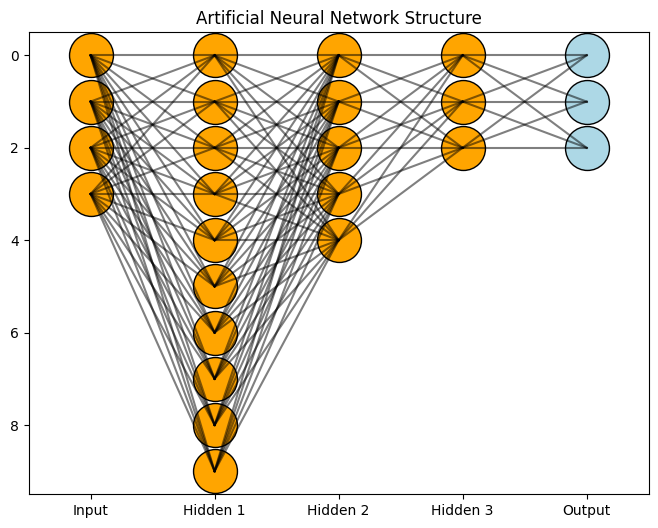

K-NN Accuracy: 0.98
Weighted K-NN Accuracy: 0.98
ANN Accuracy: 0.98


In [6]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# # Function to plot the ANN structure
# def plot_ann_structure(model, input_shape):
#     layers = [input_shape] + [layer.shape[1] for layer in model.coefs_] + [model.n_outputs_]
#     plt.figure(figsize=(8, 6))
#     for layer_idx in range(len(layers) - 1):
#         for neuron_idx in range(layers[layer_idx]):
#             for next_neuron_idx in range(layers[layer_idx + 1]):
#                 plt.plot(
#                     [layer_idx, layer_idx + 1],
#                     [neuron_idx, next_neuron_idx],
#                     'k-', alpha=0.5
#                 )
#     # Adding neurons as circles
#     for layer_idx in range(len(layers)):
#         for neuron_idx in range(layers[layer_idx]):
#             plt.scatter([layer_idx], [neuron_idx], s=1000, edgecolor='black', facecolor='orange' if layer_idx < len(layers) - 1 else 'lightblue')
#     plt.xlim(-0.5, len(layers) - 0.5)
#     plt.ylim(-0.5, max(layers) - 0.5)
#     plt.xticks(range(len(layers)), ['Input'] + [f'Hidden {i + 1}' for i in range(len(layers) - 2)] + ['Output'])
#     plt.title('Artificial Neural Network Structure')
#     plt.gca().invert_yaxis()
#     plt.grid(False)
#     plt.show()

def plot_tiny_ann(model, input_size):
    layers = [input_size] + [w.shape[1] for w in model.coefs_]
    for i in range(len(layers)-1):
        for a in range(layers[i]):
            for b in range(layers[i+1]):
                plt.plot([i, i+1], [a, b], 'k-', alpha=0.3)
    for i, n in enumerate(layers):
        for j in range(n):
            plt.scatter(i, j, c='orange', s=200, edgecolors='k')
    plt.axis('off')
    plt.show()


# Load and prepare the Iris dataset
X, y = load_iris().data,load_iris().target
# X += np.random.normal(0, 0.5, X.shape)              # Add noise
# X = StandardScaler().fit_transform(X)               # Normalize

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# K-NN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Weighted K-NN
w_knn = KNeighborsClassifier(n_neighbors=3, weights='distance')
w_knn.fit(X_train, y_train)

# ANN with default activation='relu', solver='adam'
ann = MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=2000)
ann.fit(X_train, y_train)

# Plot the ANN structure
plot_ann_structure(ann, X_train.shape[1])

# Print accuracies
print(f"K-NN Accuracy: {accuracy_score(y_test, knn.predict(X_test)):.2f}")
print(f"Weighted K-NN Accuracy: {accuracy_score(y_test, w_knn.predict(X_test)):.2f}")
print(f"ANN Accuracy: {accuracy_score(y_test, ann.predict(X_test)):.2f}")